In [17]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from math import gcd, isqrt
from fractions import Fraction
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

# CLASSICAL ALGORITHMS

In [18]:
# Factorises N by testing every divisor from 2 up to √N.
# Complexity: O(√N) — exponential in the number of bits.
# Returns (p, q, queries) where N = p * q, or (None, None, queries) if prime
def classical_trial_division(N):
    if N < 2:
        return None, None, 0
    if N % 2 == 0:
        return 2, N // 2, 1
    
    queries = 1                                 # counted the 2 check
    for i in range(3, isqrt(N) + 1, 2):
        queries += 1
        if N % i == 0:
            return i, N // i, queries
        
    return None, None, queries                  # N is prime

In [19]:
# Pollard's rho algorithm — a probabilistic sub-exponential method.
# Expected complexity: O(N^(1/4)) steps.
# Returns (p, q, queries) where N = p * q, or (None, None, queries) on failure.
def classical_pollard_rho(N, x0=2, max_iter=10_000_000):
    if N < 2:
        return None, None, 0
    if N % 2 == 0:
        return 2, N // 2, 1
    
    x, y, d, queries = x0, x0, 1, 0
    f = lambda x: (x * x + 1) % N
    while d == 1:
        x = f(x)
        y = f(f(y))
        d = gcd(abs(x - y), N)
        queries += 1
        if queries >= max_iter:
            return None, None, queries      # give up
        
    if d == N:
        return None, None, queries          # cycle detected, no factor found
    
    return d, N // d, queries

# QUANTUM ALGORITHM (Shor)

In [20]:
# Inverse Quantum Fourier Transform on the first n_count qubits.
# The QFT converts the period information encoded in the amplitudes
# into a measurable computational-basis state.
def inverse_qft(n_count):
    qc = QuantumCircuit(n_count, name='inv_QFT')

    # Bit-reversal permutation
    for j in range(n_count // 2):
        qc.swap(j, n_count - 1 - j)

    # Hadamard + controlled phase rotations
    for j in range(n_count):
        qc.h(j)
        for k in range(j + 1, n_count):
            qc.cp(-np.pi / 2 ** (k - j), k, j)
            
    return qc

In [21]:
# Quantum Phase Estimation (QPE) circuit for the unitary U|y⟩ = |a·y mod N⟩.
# The counting register encodes the phase φ = s/r  (s integer, r = ord_N(a)),
# which the classical post-processing then converts into a factor of N.
#
# n_count : precision qubits in the counting register (more ⟹ better phase resolution)
# n_target: ⌈log2 N⌉ qubits to hold the target register
#
# The modular-exponentiation gates used here are a simplified
# diagonal approximation (controlled X on each target bit where
# the corresponding bit of a^(2^j) mod N is set).  This is exact
# only when the target register happens to hold the eigenstate |1⟩,
# but it captures the dominant phase and suffices for demonstration.
def shor_qpe_circuit(N, a, n_count):
    n_target = N.bit_length()
    total = n_count + n_target
    qc = QuantumCircuit(total, n_count, name='Shor_QPE')

    # Initialise target register to |1⟩
    qc.x(n_count)

    # Put counting register into uniform superposition
    qc.h(range(n_count))

    # Controlled-U^(2^j): multiply target register by a^(2^j) mod N
    for j in range(n_count):
        exp = pow(a, 2 ** j, N)          # a^(2^j) mod N — classical pre-computation
        for q_tgt in range(n_target):
            if (exp >> q_tgt) & 1:        # bit q_tgt of exp is 1?
                qc.cx(j, n_count + q_tgt) # flip that target qubit, controlled on counting qubit j

    # Apply inverse QFT to counting register
    iqft = inverse_qft(n_count)
    qc.append(iqft, range(n_count))

    # Measure counting register
    qc.measure(range(n_count), range(n_count))
    return qc

In [22]:
# Classical post-processing: convert measurement outcomes → candidate periods r
# using the continued-fraction algorithm.
def extract_period_candidates(counts, n_count, N):
    """Returns a deduplicated list of candidate periods r from the top measurement outcomes."""
    top = sorted(counts.items(), key=lambda x: -x[1])[:12]
    candidates = []
    for bitstr, _ in top:
        measured = int(bitstr, 2)
        if measured == 0:
            continue
        phase = measured / (2 ** n_count)           # estimated phase φ ≈ s/r
        frac  = Fraction(phase).limit_denominator(N)
        r     = frac.denominator
        if r > 1 and r not in candidates:
            candidates.append(r)
    return candidates

In [23]:
# Full Shor's algorithm: QPE + classical post-processing.
# Returns the non-trivial factors of N (if found), the period r,
# the QPE circuit depth, and the wall-clock simulation time.
#
#   Parameters
#   ----------
#   N       : integer to factorise
#   a       : base for order-finding (must satisfy 1 < a < N, gcd(a,N)=1)
#   n_count : number of QPE precision qubits  (rule of thumb: 2·⌈log2 N⌉)
#   shots   : number of circuit executions on the simulator
#
#   Returns
#   -------
#   p, q, r, circuit_depth, success, elapsed_time
#
def shor_factor(N, a, n_count, shots=2000):
    # Trivial GCD check before going quantum
    g = gcd(a, N)
    if g > 1:
        return g, N // g, None, 0, True, 0.0

    qc = shor_qpe_circuit(N, a, n_count)
    circuit_depth = qc.depth()

    backend   = AerSimulator()
    transpiled = transpile(qc, backend)

    start = time.perf_counter()
    counts = backend.run(transpiled, shots=shots).result().get_counts()
    elapsed = time.perf_counter() - start

    candidates = extract_period_candidates(counts, n_count, N)

    for r in candidates:
        if r % 2 != 0:
            continue
        
        x = pow(a, r // 2, N)
        for guess in [gcd(x - 1, N), gcd(x + 1, N)]:
            if 1 < guess < N:
                return guess, N // guess, r, circuit_depth, True, elapsed

    return None, None, None, circuit_depth, False, elapsed

# DRAW CIRCUITS (printed once before the comparison loop)

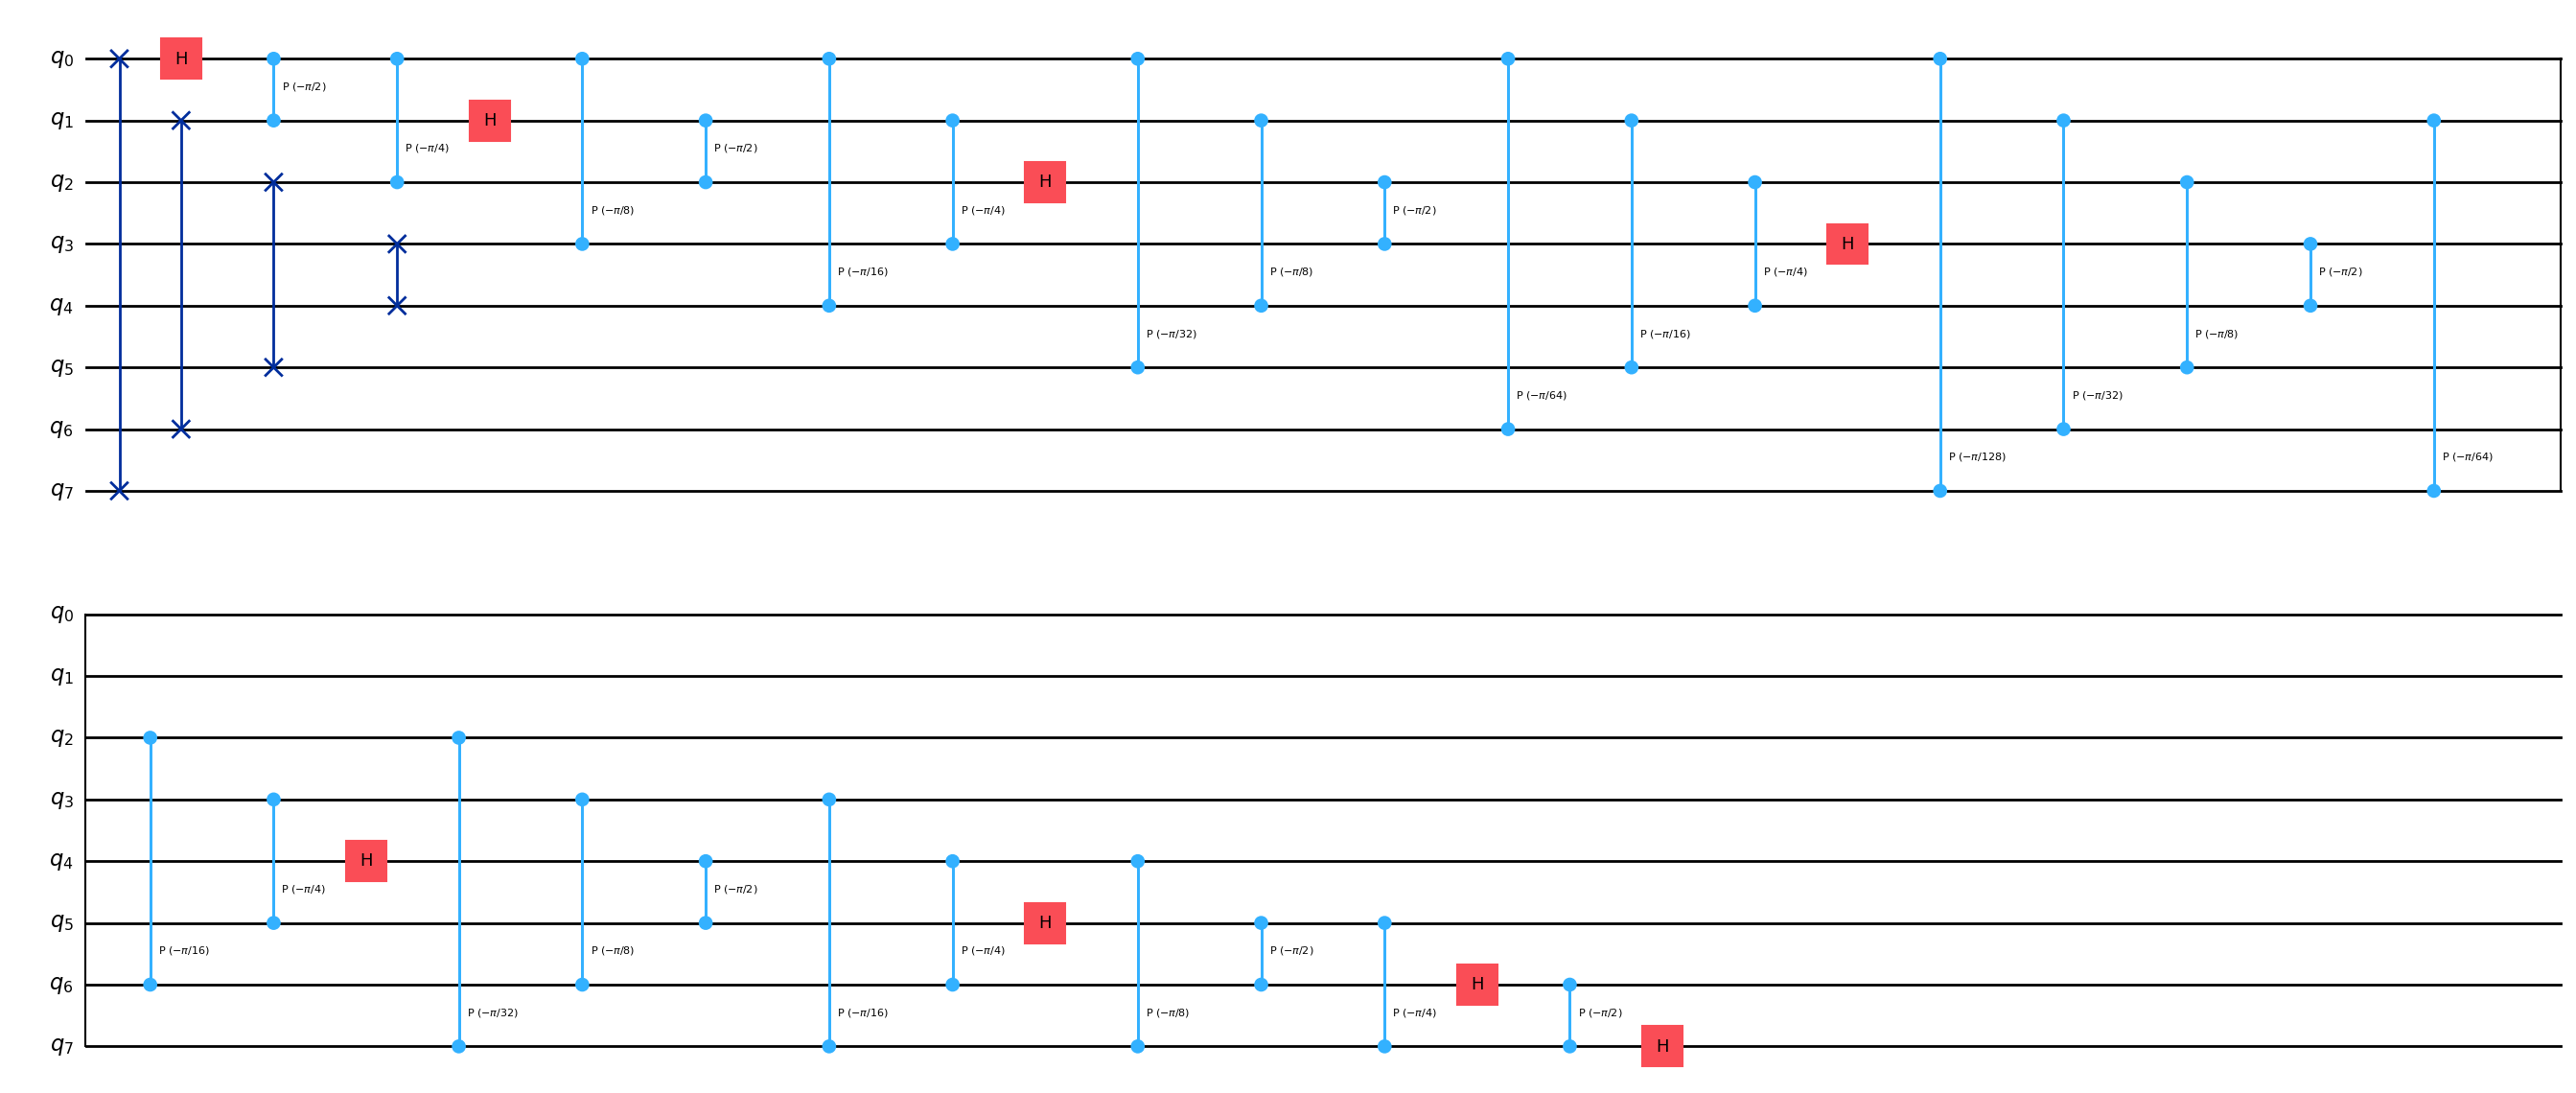

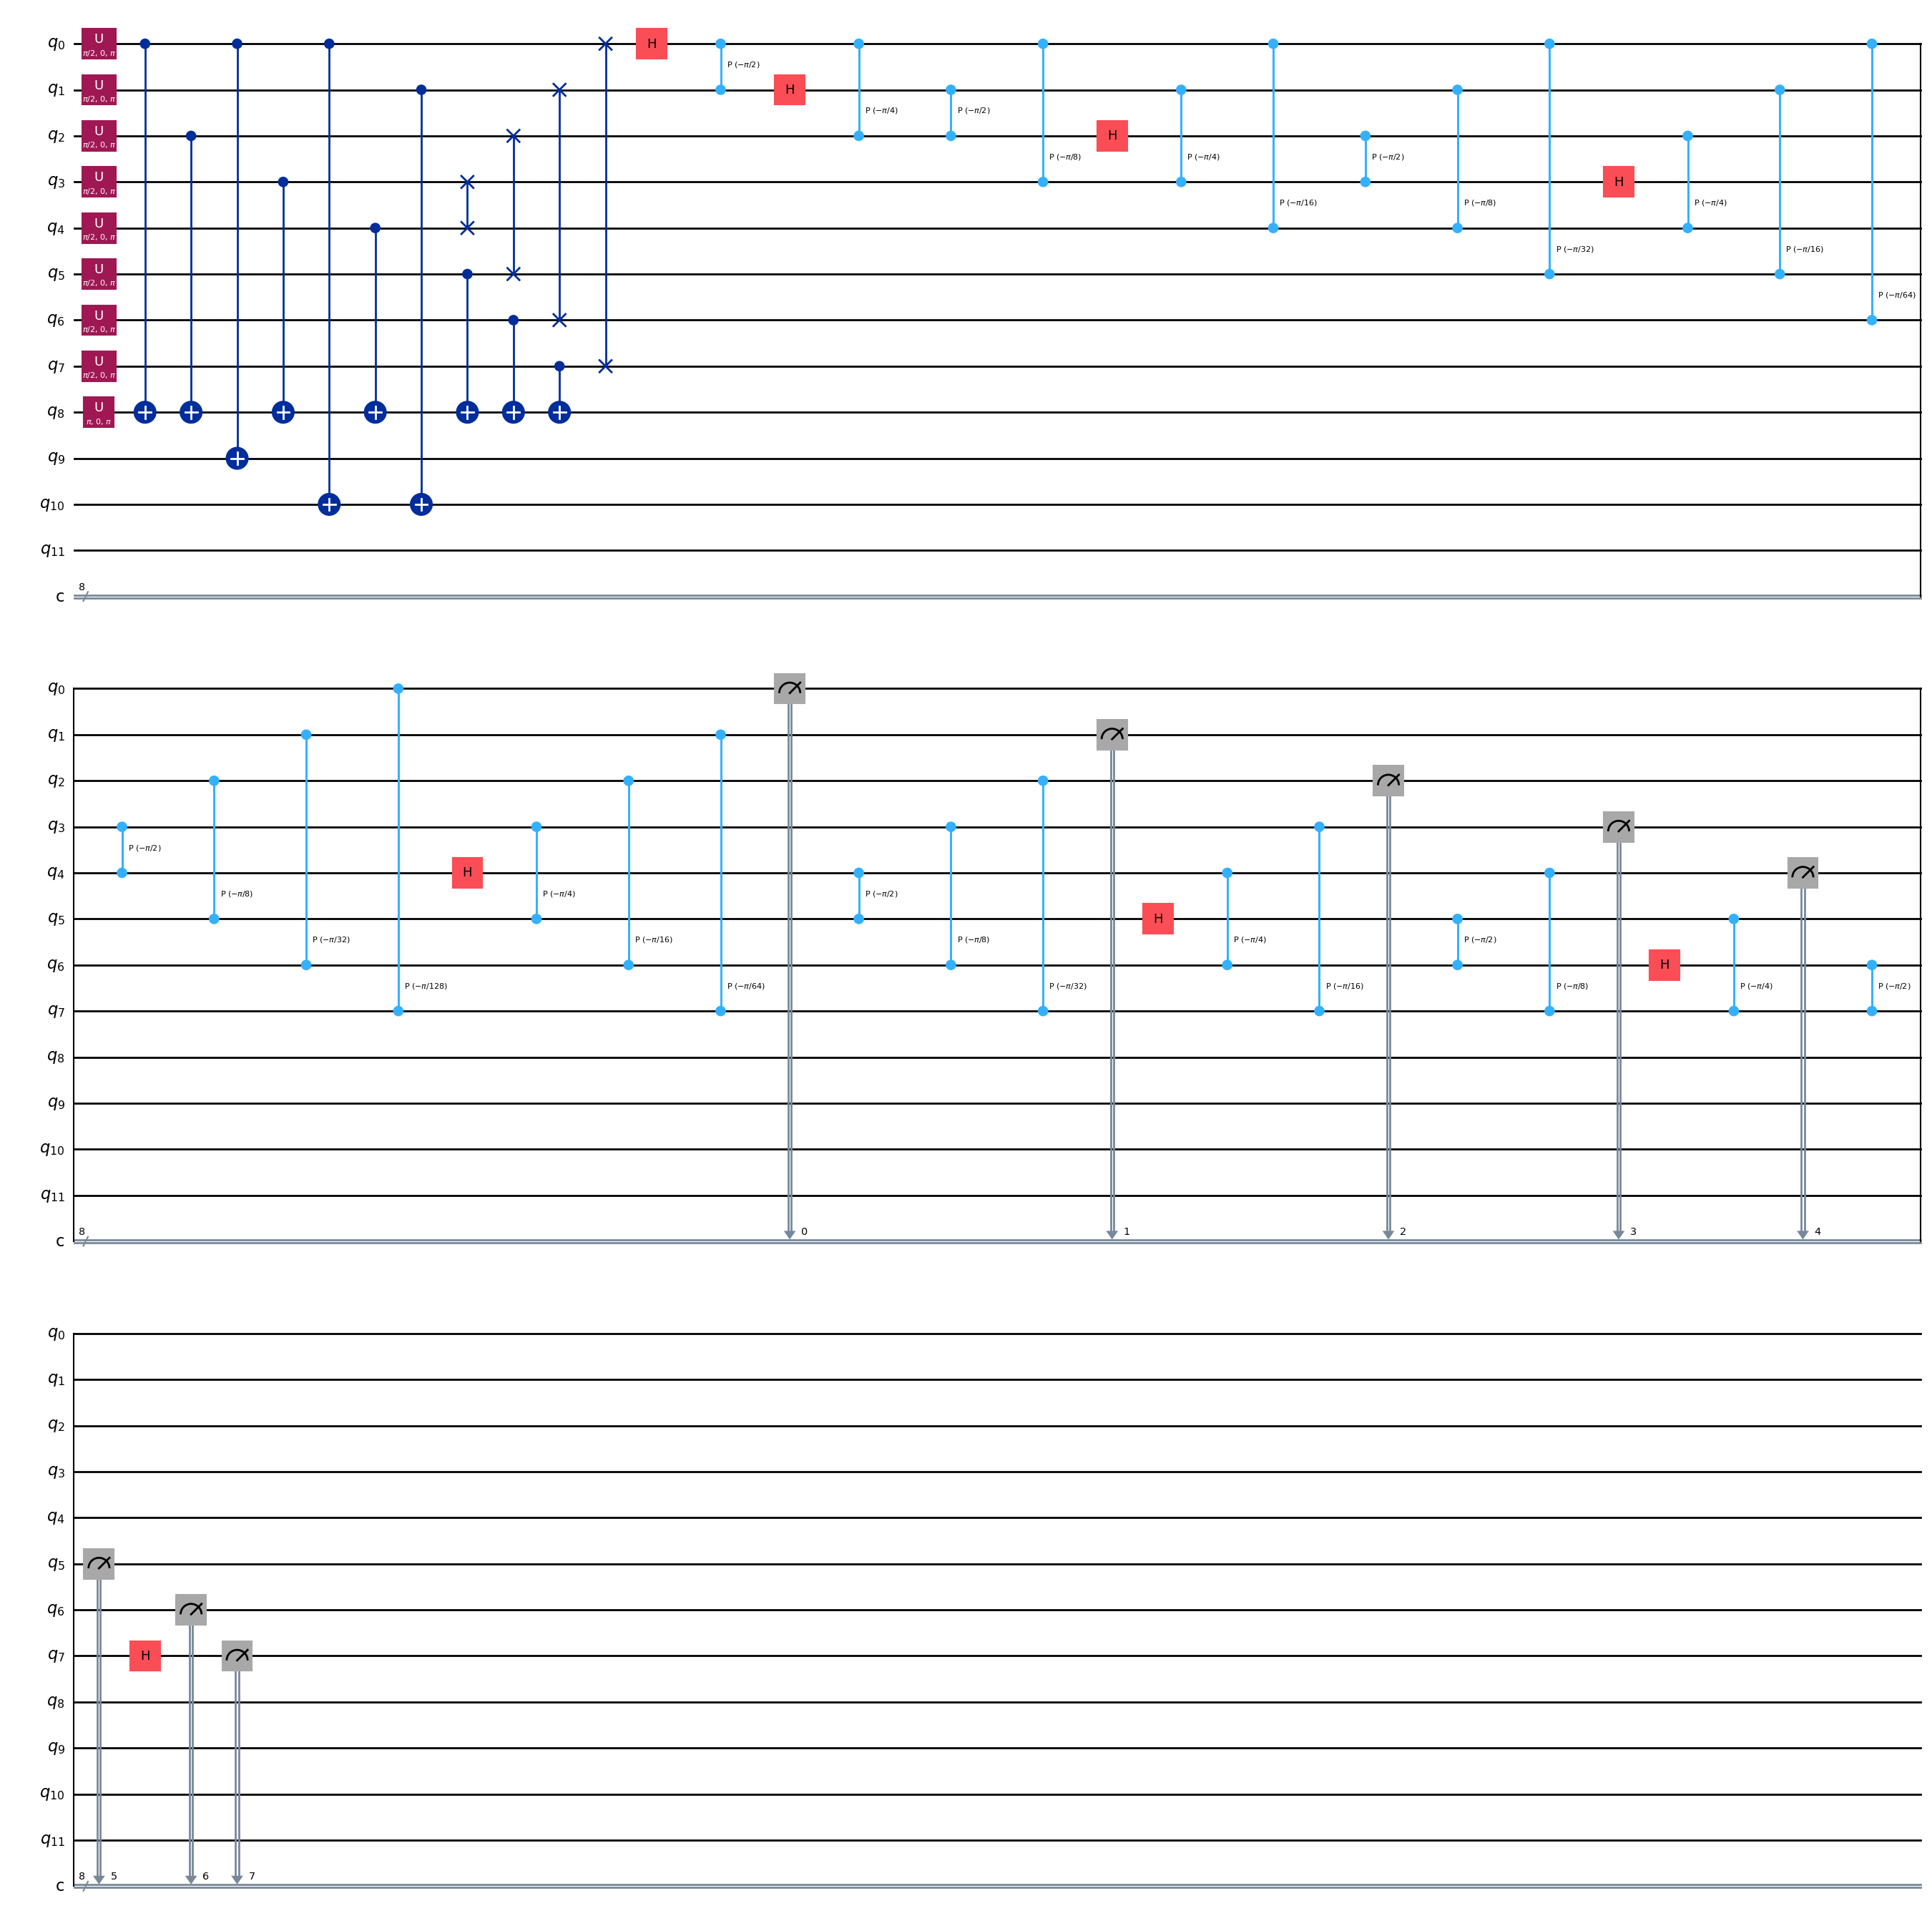

In [24]:
N_example       = 15   # Number to factorise
a_example       = 7    # Coprime base
n_count_example = 8    # QPE precision qubits

iqft_example = inverse_qft(n_count_example)
display(iqft_example.draw(output='mpl', fold=40))

qc_example = shor_qpe_circuit(N_example, a_example, n_count_example)
display(qc_example.decompose().draw(output='mpl', fold=40))

# RUN COMPARISON

In [25]:
# ── Configurable parameters ───────────────────────────────────────────────────
# List of (N, a) pairs to benchmark.  Each N must be a semiprime (product of
# two primes) and a must satisfy 1 < a < N  with gcd(a, N) = 1.
BENCHMARK_CASES = [
    (15,  7),   # 15  = 3 × 5
    (21,  2),   # 21  = 3 × 7
    (33,  2),   # 33  = 3 × 11
    (35,  2),   # 35  = 5 × 7
    (77,  2),   # 77  = 7 × 11
    (91,  2),   # 91  = 7 × 13
    (143, 2),   # 143 = 11 × 13
    (221, 2),   # 221 = 13 × 17
]
N_COUNT_MULTIPLIER = 2    # n_count = N_COUNT_MULTIPLIER * ceil(log2(N))
SHOTS              = 2000 # QPE shots per main run
RUNS               = 5    # Repeat classical algorithms this many times and average

# For Plot 3 (success rate vs n_count): fixed N and a, sweep n_count values
SUCCESS_N          = 15   # Which N to use for the success-rate sweep
SUCCESS_A          = 7    # Coprime base for that N
SUCCESS_N_COUNTS   = list(range(2, 13))  # n_count values to sweep
SUCCESS_TRIALS     = 20   # Independent QPE runs per n_count value
# ─────────────────────────────────────────────────────────────────────────────

results = {
    'N':              [],
    'n_bits':         [],
    'n_count':        [],
    'trial_queries':  [],
    'pollard_queries':[],
    'shor_depth':     [],
    'trial_time':     [],
    'pollard_time':   [],
    'shor_time':      [],
    'shor_correct':   [],
}

for N, a in BENCHMARK_CASES:
    n_bits   = N.bit_length()
    n_count  = N_COUNT_MULTIPLIER * n_bits

    print(f"N={N:>4}  (bits={n_bits})  a={a}  n_count={n_count}")

    # ── Trial division ──
    td_queries_total = 0
    td_time_total    = 0.0
    for _ in range(RUNS):
        start = time.perf_counter()
        _, _, q = classical_trial_division(N)
        td_time_total    += time.perf_counter() - start
        td_queries_total += q

    # ── Pollard's rho ──
    pr_queries_total = 0
    pr_time_total    = 0.0
    for _ in range(RUNS):
        x0 = random.randint(2, N - 1)
        start = time.perf_counter()
        _, _, q = classical_pollard_rho(N, x0=x0)
        pr_time_total    += time.perf_counter() - start
        pr_queries_total += q

    # ── Shor ──
    p, q_fac, r, depth, correct, g_time = shor_factor(N, a, n_count, shots=SHOTS)
    if correct:
        print(f"  Shor found: {N} = {p} × {q_fac}  (r={r}, depth={depth})")
    else:
        print(f"  Shor did NOT find factors (depth={depth})")

    results['N'].append(N)
    results['n_bits'].append(n_bits)
    results['n_count'].append(n_count)
    results['trial_queries'].append(td_queries_total / RUNS)
    results['pollard_queries'].append(pr_queries_total / RUNS)
    results['shor_depth'].append(depth)
    results['trial_time'].append(td_time_total / RUNS)
    results['pollard_time'].append(pr_time_total / RUNS)
    results['shor_time'].append(g_time)
    results['shor_correct'].append(correct)

# ── Success-rate sweep (for Plot 3) ──────────────────────────────────────────
print(f"\nSuccess-rate sweep: N={SUCCESS_N}, a={SUCCESS_A}, {SUCCESS_TRIALS} trials each")
success_rates = []
for nc in SUCCESS_N_COUNTS:
    hits = sum(
        shor_factor(SUCCESS_N, SUCCESS_A, nc, shots=SHOTS)[4]   # index 4 = success bool
        for _ in range(SUCCESS_TRIALS)
    )
    rate = hits / SUCCESS_TRIALS
    success_rates.append(rate)
    print(f"  n_count={nc:>2}  success={rate:.0%}")

N=  15  (bits=4)  a=7  n_count=8
  Shor found: 15 = 3 × 5  (r=4, depth=10)
N=  21  (bits=5)  a=2  n_count=10
  Shor found: 21 = 3 × 7  (r=2, depth=8)
N=  33  (bits=6)  a=2  n_count=12
  Shor did NOT find factors (depth=14)
N=  35  (bits=6)  a=2  n_count=12
  Shor found: 35 = 5 × 7  (r=4, depth=10)
N=  77  (bits=7)  a=2  n_count=14
  Shor found: 77 = 7 × 11  (r=30, depth=10)
N=  91  (bits=7)  a=2  n_count=14
  Shor did NOT find factors (depth=12)
N= 143  (bits=8)  a=2  n_count=16
  Shor found: 143 = 11 × 13  (r=60, depth=16)
N= 221  (bits=8)  a=2  n_count=16
  Shor found: 221 = 17 × 13  (r=8, depth=18)

Success-rate sweep: N=15, a=7, 20 trials each
  n_count= 2  success=100%
  n_count= 3  success=100%
  n_count= 4  success=100%
  n_count= 5  success=100%
  n_count= 6  success=100%
  n_count= 7  success=100%
  n_count= 8  success=100%
  n_count= 9  success=100%
  n_count=10  success=100%
  n_count=11  success=100%
  n_count=12  success=100%


# PLOT 1 — Queries / Circuit depth

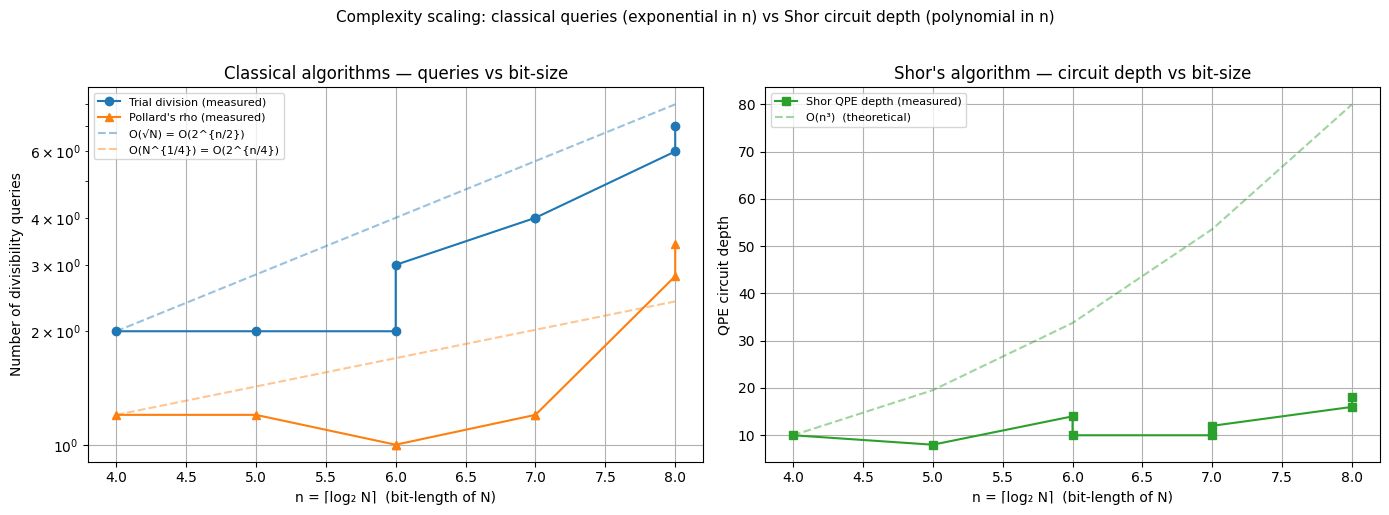

In [26]:
# ── Complexity scaling — classical queries vs Shor circuit depth ──────
# The two algorithms live on fundamentally different scales:
#   Classical queries grow with N  (exponential in n_bits)
#   Shor's circuit depth grows with n_bits  (polynomial)
# We therefore use TWO separate subplots, both with n_bits on the x-axis,
# and overlay the theoretical asymptotic curves for visual reference.

n_bits_arr = np.array(results['n_bits'])
N_arr      = 2.0 ** n_bits_arr          # theoretical N from bit count

# Theoretical curves (normalised to match the first data point)
# Scale theory curve so it passes through the first data point
def normalise(theory, data):
    return theory * (data[0] / theory[0])

th_trial   = normalise(np.sqrt(N_arr),         np.array(results['trial_queries']))
th_pollard = normalise(N_arr ** 0.25,           np.array(results['pollard_queries']))
th_shor    = normalise(n_bits_arr ** 3,         np.array(results['shor_depth'], dtype=float))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: classical algorithms — queries vs n_bits
ax1.plot(n_bits_arr, results['trial_queries'],   'o-', color='tab:blue',   label='Trial division (measured)')
ax1.plot(n_bits_arr, results['pollard_queries'], '^-', color='tab:orange', label="Pollard's rho (measured)")
ax1.plot(n_bits_arr, th_trial,   '--', color='tab:blue',   alpha=0.45, label='O(√N) = O(2^{n/2})')
ax1.plot(n_bits_arr, th_pollard, '--', color='tab:orange', alpha=0.45, label='O(N^{1/4}) = O(2^{n/4})')
ax1.set_xlabel('n = ⌈log₂ N⌉  (bit-length of N)')
ax1.set_ylabel('Number of divisibility queries')
ax1.set_title('Classical algorithms — queries vs bit-size')
ax1.set_yscale('log')
ax1.legend(fontsize=8)
ax1.grid(True)

# Right: Shor QPE — circuit depth vs n_bits
ax2.plot(n_bits_arr, results['shor_depth'], 's-', color='tab:green', label='Shor QPE depth (measured)')
ax2.plot(n_bits_arr, th_shor,              '--', color='tab:green', alpha=0.45, label='O(n³)  (theoretical)')
ax2.set_xlabel('n = ⌈log₂ N⌉  (bit-length of N)')
ax2.set_ylabel('QPE circuit depth')
ax2.set_title("Shor's algorithm — circuit depth vs bit-size")
ax2.legend(fontsize=8)
ax2.grid(True)

fig.suptitle(
    'Complexity scaling: classical queries (exponential in n) vs Shor circuit depth (polynomial in n)',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

# PLOT 2 — Actual execution time

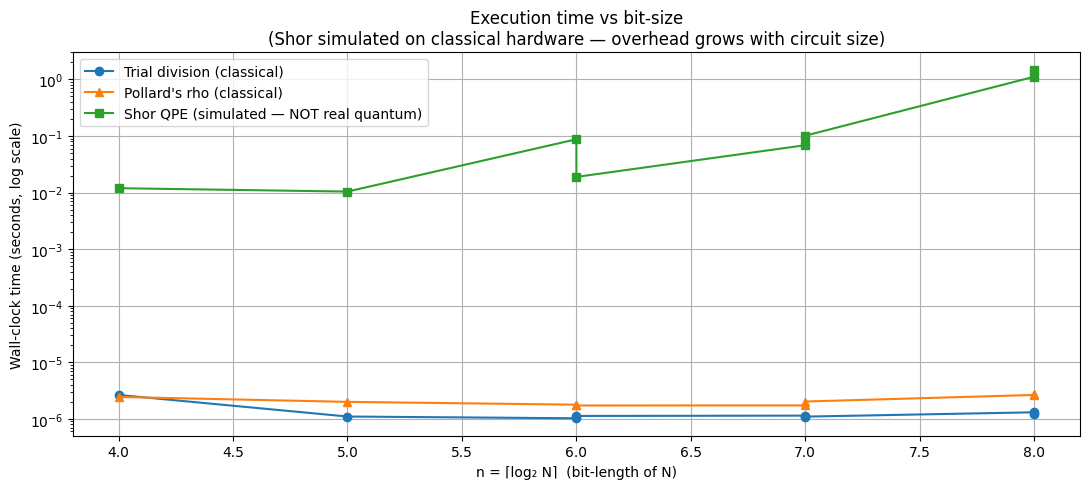

In [27]:
# ── Plot 2: Actual wall-clock simulation time vs n_bits ───────────────────────
# Important caveat: Shor is running on a CLASSICAL SIMULATOR, so its time
# reflects the cost of simulating quantum circuits, not true quantum execution.
# On a real quantum computer the Shor column would collapse to seconds regardless
# of N; the classical columns would grow super-exponentially.

plt.figure(figsize=(11, 5))
plt.plot(n_bits_arr, results['trial_time'],   'o-', color='tab:blue',   label='Trial division (classical)')
plt.plot(n_bits_arr, results['pollard_time'], '^-', color='tab:orange', label="Pollard's rho (classical)")
plt.plot(n_bits_arr, results['shor_time'],    's-', color='tab:green',  label='Shor QPE (simulated — NOT real quantum)')
plt.xlabel('n = ⌈log₂ N⌉  (bit-length of N)')
plt.ylabel('Wall-clock time (seconds, log scale)')
plt.title('Execution time vs bit-size\n(Shor simulated on classical hardware — overhead grows with circuit size)')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# PLOT 3 — QPE success rate vs n_count

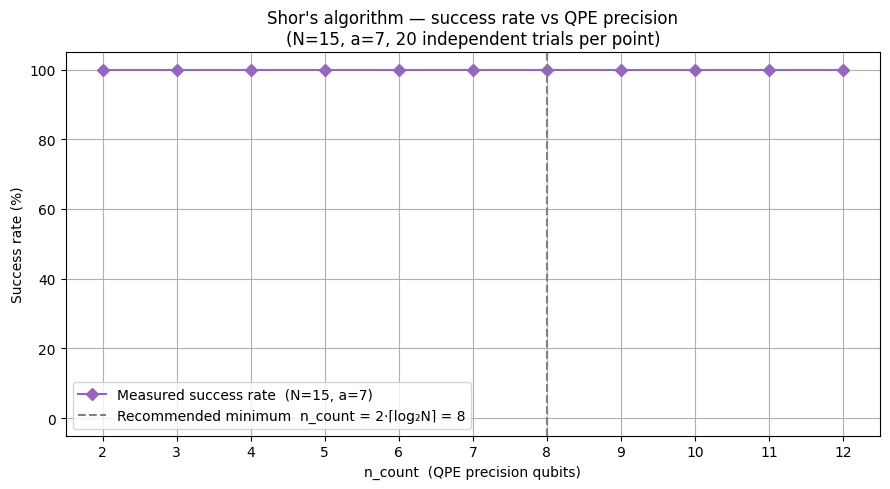

In [28]:
# ── Success rate vs QPE precision qubits ──────────────────────────────
# This plot is specific to Shor and has no analogue in Grover.
#
# n_count controls the phase resolution of the QPE step:
#   - Too few qubits → the measured phase is too coarse to recover r exactly
#     via continued fractions → factorisation fails.
#   - Theory guarantees success with high probability once n_count ≥ 2·⌈log₂ N⌉.
#
# The vertical dashed line marks the recommended minimum (2·⌈log₂ N⌉).

n_min_theory = 2 * SUCCESS_N.bit_length()

plt.figure(figsize=(9, 5))
plt.plot(SUCCESS_N_COUNTS, [r * 100 for r in success_rates],
         'D-', color='tab:purple', label=f'Measured success rate  (N={SUCCESS_N}, a={SUCCESS_A})')
plt.axvline(n_min_theory, color='gray', linestyle='--',
            label=f'Recommended minimum  n_count = 2·⌈log₂N⌉ = {n_min_theory}')
plt.xlabel('n_count  (QPE precision qubits)')
plt.ylabel('Success rate (%)')
plt.title(
    f"Shor's algorithm — success rate vs QPE precision\n"
    f"(N={SUCCESS_N}, a={SUCCESS_A}, {SUCCESS_TRIALS} independent trials per point)"
)
plt.ylim(-5, 105)
plt.xticks(SUCCESS_N_COUNTS)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# PRINT SUMMARY

In [29]:
header = f"{'N':>6} {'bits':>5} {'n_count':>8} {'Trial Q':>9} {'Pollard Q':>10} {'QPE depth':>10} {'Correct':>8}"
print(header)
print("-" * len(header))
for i in range(len(results['N'])):
    print(
        f"{results['N'][i]:>6} "
        f"{results['n_bits'][i]:>5} "
        f"{results['n_count'][i]:>8} "
        f"{results['trial_queries'][i]:>9.1f} "
        f"{results['pollard_queries'][i]:>10.1f} "
        f"{results['shor_depth'][i]:>10} "
        f"{'Yes' if results['shor_correct'][i] else 'No':>8}"
    )

print(f"\nSuccess-rate sweep  (N={SUCCESS_N}, a={SUCCESS_A}, {SUCCESS_TRIALS} trials each):")
print(f"  {'n_count':>8}  {'success':>8}")
print("  " + "-" * 19)
for nc, rate in zip(SUCCESS_N_COUNTS, success_rates):
    marker = '  ← recommended minimum' if nc == 2 * SUCCESS_N.bit_length() else ''
    print(f"  {nc:>8}  {rate:>7.0%}{marker}")

     N  bits  n_count   Trial Q  Pollard Q  QPE depth  Correct
--------------------------------------------------------------
    15     4        8       2.0        1.2         10      Yes
    21     5       10       2.0        1.2          8      Yes
    33     6       12       2.0        1.0         14       No
    35     6       12       3.0        1.0         10      Yes
    77     7       14       4.0        1.2         10      Yes
    91     7       14       4.0        1.2         12       No
   143     8       16       6.0        2.8         16      Yes
   221     8       16       7.0        3.4         18      Yes

Success-rate sweep  (N=15, a=7, 20 trials each):
   n_count   success
  -------------------
         2     100%
         3     100%
         4     100%
         5     100%
         6     100%
         7     100%
         8     100%  ← recommended minimum
         9     100%
        10     100%
        11     100%
        12     100%
